# Импорт библиотек

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Загрузка датасета

In [2]:
file_path = "insurance.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "abdullahcetin/mirichoi0218insurance",
  file_path,
)

/tmp/ipykernel_1287/3696586206.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 54.3k/54.3k [00:00<00:00, 949kB/s]


In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Предобработка данных

## 1. Проверка типов данных

In [5]:
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

types_df = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "уникальных значений": df.nunique(),
    "пример": df.iloc[0],
})
types_df

,тип,уникальных значений,пример
age,int64,47,19
sex,object,2,female
bmi,float64,548,27.9
children,int64,6,0
smoker,object,2,yes
region,object,4,southwest
charges,float64,1337,16884.924


In [6]:
for col in numeric_cols:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Столбец {col} не числовой ({df[col].dtype}) — преобразуем")
        df[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        print(f"Столбец {col}: тип {df[col].dtype} — ок")

Столбец age: тип int64 — ок
Столбец bmi: тип float64 — ок
Столбец children: тип int64 — ок
Столбец charges: тип float64 — ок


## 2. Обнаружение и обработка пропусков

In [7]:
missing = df.isna().sum()
pd.DataFrame({
    "пропусков": missing,
    "доля, %": (missing / len(df) * 100).round(2),
})

,пропусков,"доля, %"
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


## 3. Поиск и удаление дубликатов

In [8]:
print("Полностью совпадающих строк:", df.duplicated().sum())

df[df.duplicated(keep=False)]

Полностью совпадающих строк: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Удалено дубликатов: {rows_before - len(df)}. Строк осталось: {len(df)}")

Удалено дубликатов: 1. Строк осталось: 1337


# Визуализация данных

## 1. Распределения числовых показателей

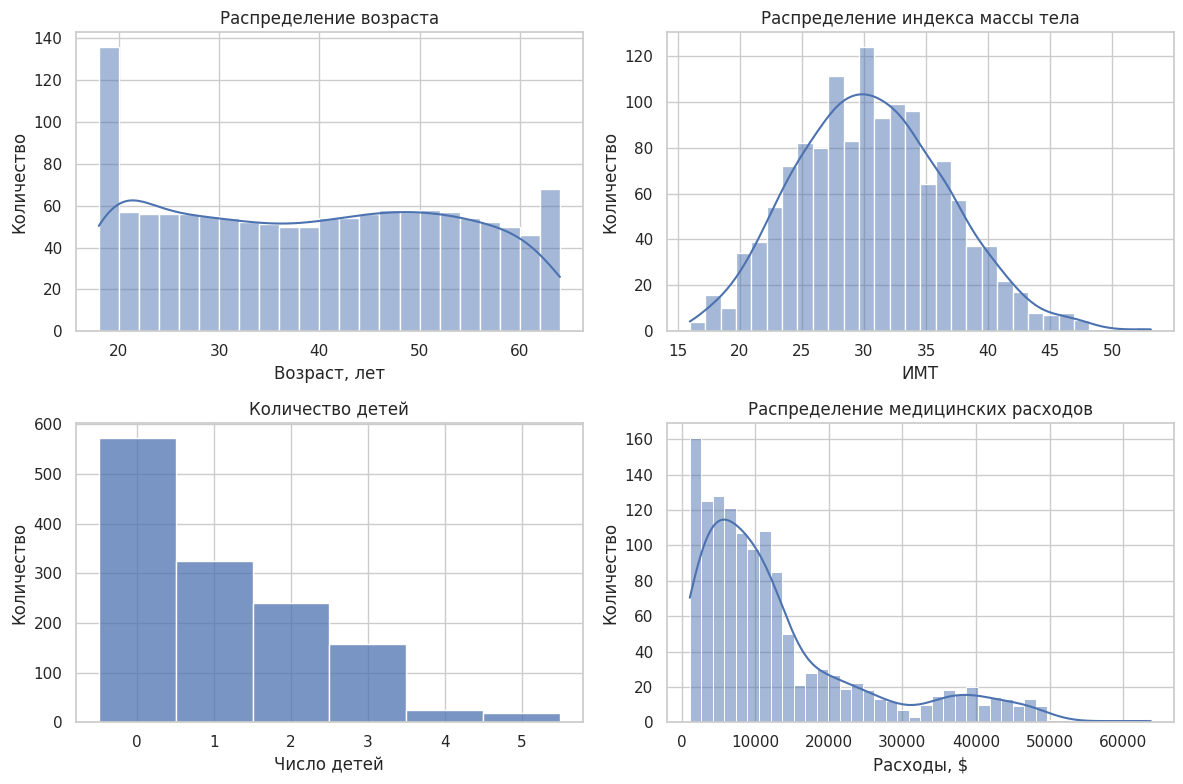

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["age"], bins=23, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Распределение возраста")
axes[0, 0].set_xlabel("Возраст, лет")

sns.histplot(df["bmi"], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Распределение индекса массы тела")
axes[0, 1].set_xlabel("ИМТ")

sns.histplot(df["children"], discrete=True, ax=axes[1, 0])
axes[1, 0].set_title("Количество детей")
axes[1, 0].set_xlabel("Число детей")

sns.histplot(df["charges"], bins=40, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Распределение медицинских расходов")
axes[1, 1].set_xlabel("Расходы, $")

for ax in axes.flat:
    ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()

## 2. Категориальные признаки

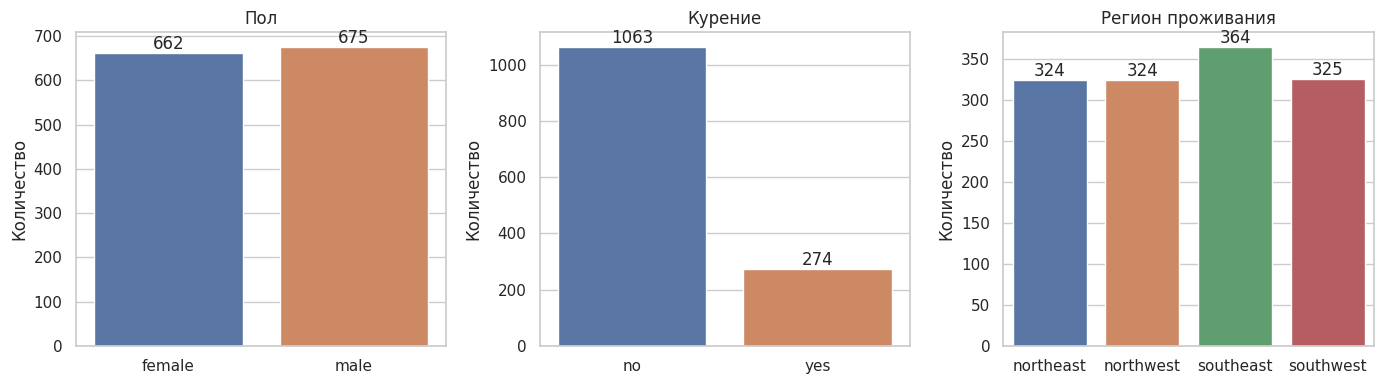

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(
    axes, ["sex", "smoker", "region"],
    ["Пол", "Курение", "Регион проживания"],
):
    sns.countplot(data=df, x=col, hue=col, dodge=False, legend=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Количество")
    for container in ax.containers:
        ax.bar_label(container)
plt.tight_layout()
plt.show()

## 3. Медицинские расходы в разрезе категориальных признаков

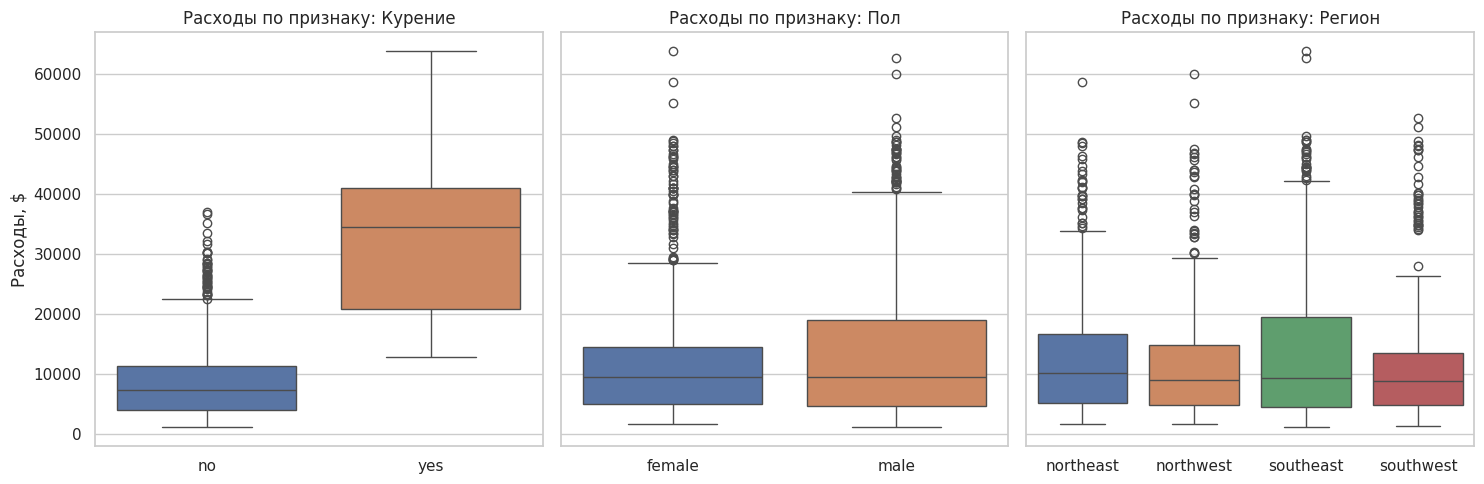

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, col, title in zip(
    axes, ["smoker", "sex", "region"],
    ["Курение", "Пол", "Регион"],
):
    sns.boxplot(data=df, x=col, y="charges", hue=col, dodge=False, legend=False, ax=ax)
    ax.set_title(f"Расходы по признаку: {title}")
    ax.set_xlabel("")
    ax.set_ylabel("Расходы, $")
plt.tight_layout()
plt.show()

## 4. Зависимость расходов от возраста и индекса массы тела

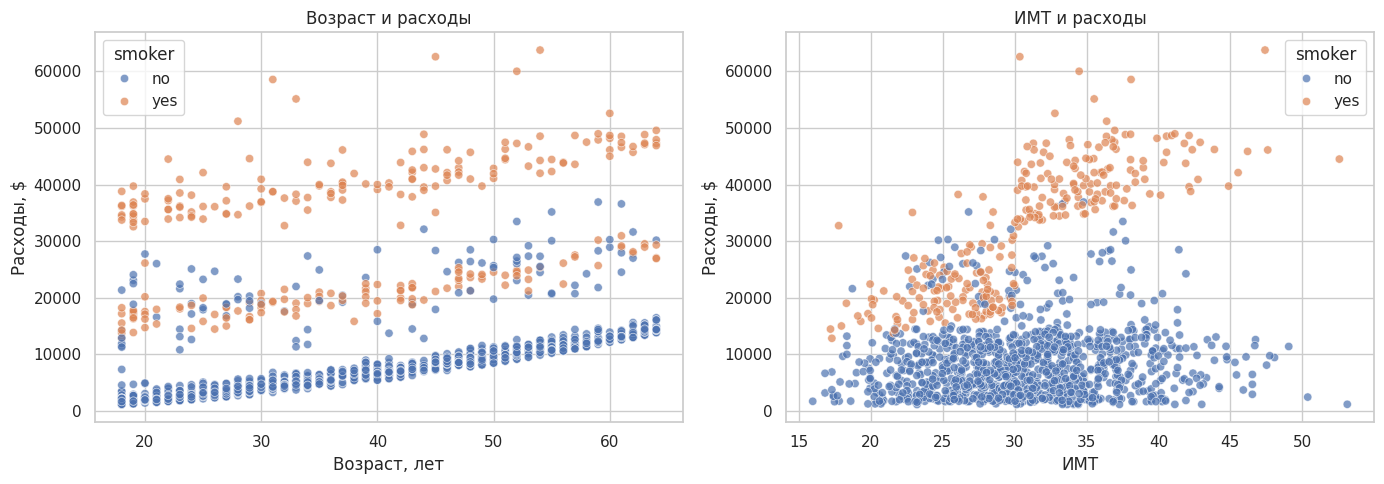

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.7, ax=axes[0])
axes[0].set_title("Возраст и расходы")
axes[0].set_xlabel("Возраст, лет")
axes[0].set_ylabel("Расходы, $")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7, ax=axes[1])
axes[1].set_title("ИМТ и расходы")
axes[1].set_xlabel("ИМТ")
axes[1].set_ylabel("Расходы, $")

plt.tight_layout()
plt.show()